# Customer Churn Analytics

## Business Problem

Customer churn is a major challenge for banks because acquiring a new customer is typically more expensive than retaining an existing one.

This project analyzes customer churn data to:

- Identify customer segments most likely to leave
- Understand factors influencing churn
- Build a predictive model for churn detection
- Generate business recommendations for improving customer retention

## Project Objectives

1. Explore customer behavior through EDA
2. Identify key churn drivers
3. Build a churn prediction model
4. Translate findings into actionable business insights

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Churn_Modelling.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 10000
Columns: 14


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Exploratory Data Analysis

The goal of the EDA is to understand:

- Overall churn distribution
- Demographic factors
- Geographic patterns
- Product usage behavior
- Customer engagement patterns

The analysis focuses on identifying business factors associated with customer churn.

In [2]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [3]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

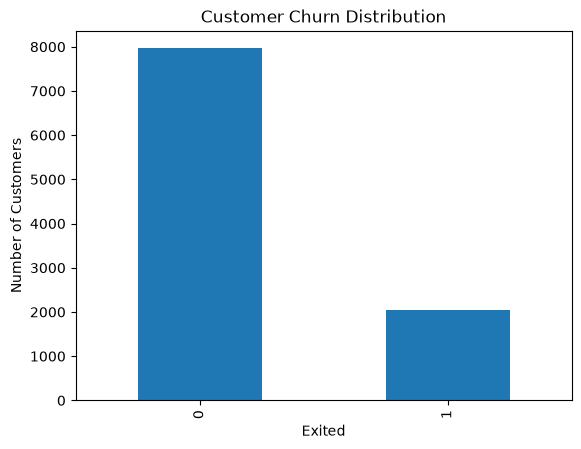

In [4]:
import matplotlib.pyplot as plt

df["Exited"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

In [5]:
df.groupby("Gender")["Exited"].mean() * 100

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [6]:
df.groupby("Geography")["Exited"].mean() * 100

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

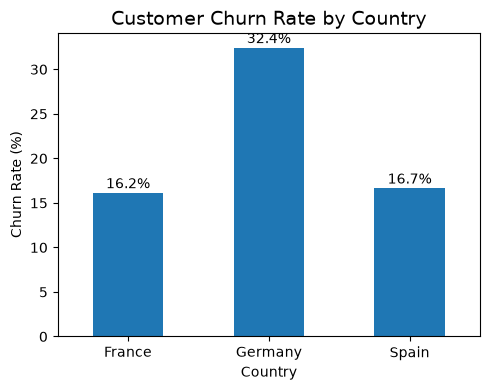

In [7]:
churn_geo = df.groupby("Geography")["Exited"].mean() * 100

plt.figure(figsize=(5,4))

ax = churn_geo.plot(kind="bar")

plt.title("Customer Churn Rate by Country", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

for i, value in enumerate(churn_geo):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

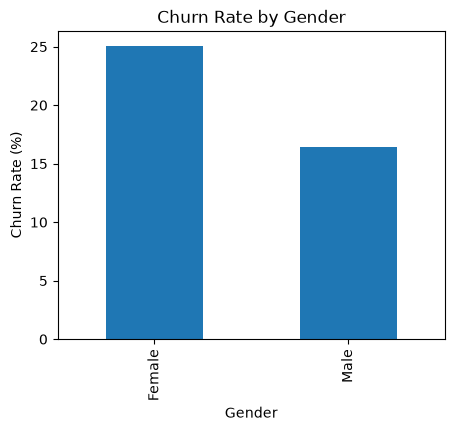

In [8]:
churn_gender = df.groupby("Gender")["Exited"].mean() * 100
plt.figure(figsize=(5,4))
churn_gender.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

In [9]:
df.groupby("HasCrCard")["Exited"].mean() * 100

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

In [10]:
df.groupby("NumOfProducts")["Exited"].mean() * 100

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

In [11]:
df["NumOfProducts"].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [12]:
df.groupby("IsActiveMember")["Exited"].mean() * 100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [13]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","31-40","41-50","51-60","60+"]
)

age_churn = df.groupby("AgeGroup")["Exited"].mean() * 100

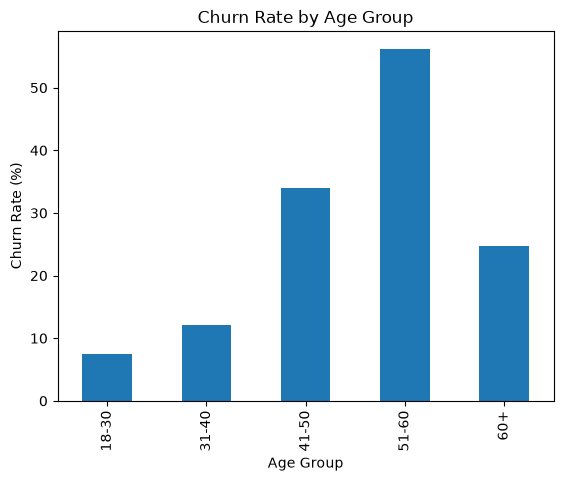

In [14]:
age_churn.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

### Insight

Customer churn increases with age.

Customers aged 51–60 exhibit the highest churn rates, indicating that older customer segments may require targeted retention strategies.

In [15]:
df["BalanceGroup"] = pd.cut(
    df["Balance"],
    bins=5
)

df.groupby("BalanceGroup")["Exited"].mean() * 100

BalanceGroup
(-250.898, 50179.618]       14.247021
(50179.618, 100359.236]     19.960861
(100359.236, 150538.854]    25.783699
(150538.854, 200718.472]    21.748634
(200718.472, 250898.09]     59.375000
Name: Exited, dtype: float64

# Exploratory Data Analysis (EDA)

## Key Findings

1. Churn rate is 20.37%.

2. Germany has the highest churn rate (32.4%).

3. Female customers churn more frequently (25.1%) than male customers (16.5%).

4. Inactive customers churn nearly twice as often as active customers.

5. Churn increases significantly with age, peaking at 56.2% among customers aged 51–60.

6. Customers with 3–4 products show unusually high churn rates, though sample sizes are small.

7. Higher balance groups tend to exhibit higher churn rates.

# Data Preprocessing

Before model training, the dataset must be prepared.

The following steps are performed:

- Remove identifier columns that do not provide predictive value
- Encode categorical variables
- Separate features and target variable
- Split data into training and testing sets
- Standardize numerical features

These steps ensure that the machine learning model can learn meaningful patterns from the data.

In [16]:
df_model = df.copy()

df_model.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceGroup
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,"(-250.898, 50179.618]"
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,"(50179.618, 100359.236]"
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,"(150538.854, 200718.472]"
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,"(-250.898, 50179.618]"
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,"(100359.236, 150538.854]"


In [17]:
df_model = df_model.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,"(-250.898, 50179.618]"
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,"(50179.618, 100359.236]"
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,"(150538.854, 200718.472]"
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,"(-250.898, 50179.618]"
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,"(100359.236, 150538.854]"


In [18]:
df_model = df_model.drop(
    columns=["AgeGroup", "BalanceGroup"]
)

df_model.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

In [19]:
df_model = pd.get_dummies(
    df_model,
    columns=["Geography", "Gender"],
    drop_first=True
)

df_model.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Feature Selection

The target variable is:

Exited

where:

- 1 = Customer Churned
- 0 = Customer Retained

All remaining variables are used as predictive features.

In [20]:
X = df_model.drop("Exited", axis=1)
y = df_model["Exited"]

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeling

Logistic Regression was selected as the baseline model because:

- It is widely used for binary classification
- It provides interpretable results
- It performs well on structured business datasets
- It is commonly used in customer churn prediction

The model predicts whether a customer is likely to leave the bank.

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [24]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.808


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [27]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 3))

ROC-AUC Score: 0.775


### ROC-AUC Interpretation

ROC-AUC measures the model's ability to distinguish between customers who churn and those who stay.

A higher ROC-AUC score indicates better discrimination performance across different classification thresholds.

## Initial Model Evaluation

The first model provides a baseline understanding of churn prediction performance.

Because customer churn represents only around 20% of customers, the dataset is imbalanced.

A second model using class balancing will therefore be evaluated.

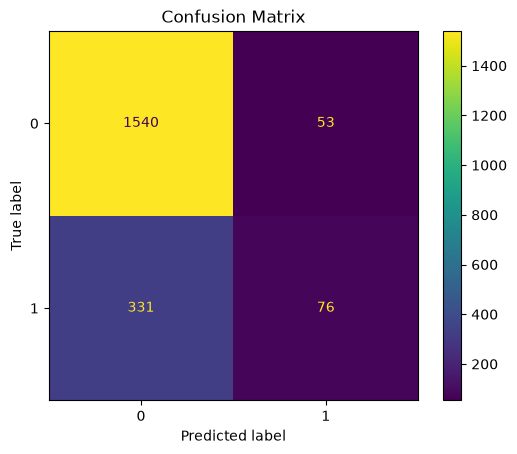

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Confusion Matrix")
plt.show()

## Handling Class Imbalance

In churn prediction, identifying churners is often more important than maximizing overall accuracy.

To improve detection of churning customers, a class-balanced Logistic Regression model is trained.

In [29]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [30]:
y_pred_balanced = balanced_model.predict(X_test_scaled)

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



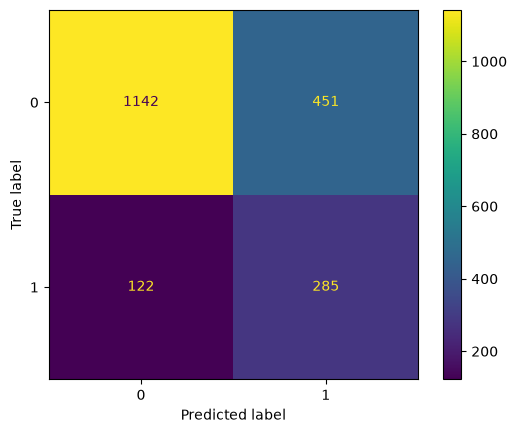

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_balanced)

ConfusionMatrixDisplay(cm).plot()
plt.show()

# Business Recommendations

## 1. Focus Retention Efforts in Germany

Germany exhibited the highest churn rate among all regions, indicating a need for targeted retention strategies.

## 2. Re-engage Inactive Customers

Inactive customers were significantly more likely to churn. Personalized engagement campaigns could improve retention.

## 3. Monitor Older Customer Segments

Customers aged 51–60 showed elevated churn risk and may benefit from specialized relationship management programs.

## 4. Track High-Balance Customers

Higher-balance customers demonstrated greater churn risk. Retaining these customers could protect valuable revenue.

## 5. Use Predictive Analytics for Early Intervention

The churn prediction model can help identify at-risk customers before they leave, allowing proactive retention efforts.

# Conclusion

This project analyzed customer churn in a retail banking dataset using exploratory data analysis and Logistic Regression.

Key findings showed that geography, customer activity, age, and product usage significantly influence churn behavior.

A predictive model was developed to identify customers at risk of leaving, enabling proactive retention strategies.

The analysis demonstrates how data-driven insights can support customer retention and business decision-making in the banking sector.